# Modèle de référence sain — NIST 14 & 16 SEER

Le 0,602 leave-one-machine-out de `EDA_NIST_model.ipynb` vient d'un baseline **rustique** :
médiane des 5 essais sains les plus proches en `(T_source, T_sink)`, **dans la même machine**.
NIST ajuste un **polynôme d'ordre 2** sur température extérieure, intérieure **et point de rosée intérieur**
(`1703_VDC_KahnDewTempF`) — ce troisième terme n'était pas utilisé.

**Question :** le plafond de transfert est-il à ~0,65 ou à ~0,80 ?
Un 0,62 est un résultat valable : ça ne vaut pas le coup d'investir davantage dans la référence.

### Protocole — non négociable

1. **Leave-one-machine-out** partout. Entraîner sur la 14 SEER, tester sur la 16, puis l'inverse, moyenner.
2. Le modèle de référence s'ajuste **uniquement sur les essais sains de la machine d'entraînement**.
   Jamais la machine de test, jamais une ligne défaillante. Le vrai risque est la **fuite**, pas le score.
   Un fit sur tout le jeu sain peut donner ~0,85 et être faux sans lever d'erreur.
3. `EF`, `CF`, `LL`, `UC/OC`, `NF` ne sont **jamais** des features — ce sont la cible.
4. Pression d'aspiration = `1701_ODVapSV_psia`, **pas** `1710_ODSuctPort_psia`
   (identique au refoulement sur la 16 SEER, 55 % du jeu).

Chargement et conversions : mêmes que `EDA_NIST_model.ipynb`. Classifieur identique :
`GradientBoostingClassifier(random_state=42)`, **résidus seuls** (le jeu gagnant à 0,602).

> **Données non versionnées.** Les deux classeurs NIST (8,5 Mo) ne sont pas dans le dépôt.
> Les télécharger depuis la page publique NIST *Fault Detection and Diagnosis Research Data*
> et les placer dans `data/nist/`.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.ensemble import GradientBoostingClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'requirements.txt').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
NIST = ROOT / 'data' / 'nist'
assert (NIST / 'fdd_1416seer.xlsx').exists(), 'Placer les xlsx NIST dans data/nist/ (non versionnés).'

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.edgecolor': GRID,
    'axes.labelcolor': MUTED, 'text.color': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10,
})

F2C = lambda s: (s - 32) * 5 / 9
dF2K = lambda s: s * 5 / 9
PSI2BAR, BTU2W = 0.0689476, 0.293071

df = pd.read_excel(NIST / 'fdd_1416seer.xlsx')

FAULTCOLS = {'EF': 'Evap_Airflow', 'CF': 'Cond_Blockage', 'LL': 'LiquidLine', 'UC/OC': 'Charge'}

def fault_label(row, tol=2.0):
    active = []
    for col, name in FAULTCOLS.items():
        v = row[col]
        if pd.isna(v) or abs(v - 100) <= tol:
            continue
        if name == 'Charge':
            name = 'Undercharge' if v < 100 else 'Overcharge'
        active.append(name)
    if not active:
        return 'No_Fault'
    return active[0] if len(active) == 1 else 'MULTI:' + '+'.join(sorted(active))

df['fault_class'] = df.apply(fault_label, axis=1)

# Piège 16 SEER : 1710 est identique au refoulement (capteur non instrumenté).
m16 = df.Rated_SEER == 16.0
assert (df.loc[m16, '1710_ODSuctPort_psia'] == df.loc[m16, 'CompDisch_psia']).all()

X = pd.DataFrame(index=df.index)
X['P_evap'] = df['1701_ODVapSV_psia'] * PSI2BAR          # ← pas 1710
X['P_cond'] = df['CompDisch_psia'] * PSI2BAR
X['pressure_ratio'] = X.P_cond / X.P_evap
X['T_suction'] = F2C(df['1608_CompSuct_TempF'])
X['T_discharge'] = F2C(df['1617_CompDisch_TempF'])
X['T_evap'] = F2C(df['CompSuct_Tsat_F'])
X['T_cond'] = F2C(df['CompDisch_Tsat_F'])
X['superheat'] = dF2K(df['CompSuct_Suph_F'])
X['subcooling'] = dF2K(df['ODLiqSV_Tsub_F'])
X['Q_evap'] = df['TOTAL Capacity (Btu/h)'] * BTU2W        # filtre NaN, pas une cible résiduelle
X['W_od'] = df['OD_Xitron_Watts']
X['COP'] = df['COP']
X['T_source'] = F2C(df['Inlet TC Grid AVG Temp (F)'])     # évaporateur = intérieur
X['T_sink'] = F2C(df['OD Air AVG DB (F)'])                # condenseur  = extérieur
X['T_dew'] = F2C(df['1703_VDC_KahnDewTempF'])             # point de rosée intérieur
X['delta_T_evap'] = X.T_source - X.T_evap
X['delta_T_cond'] = X.T_cond - X.T_sink

LEAK = ['EF', 'CF', 'LL', 'UC/OC', 'NF']
assert not any(c in X.columns for c in LEAK), 'fuite : niveaux de défaut dans X'

y, grp = df.fault_class, df.Rated_SEER
keep = (
    grp.isin([14.0, 16.0])
    & (~y.str.startswith('MULTI'))
    & X.notna().all(axis=1)
)
X, y, grp = X.loc[keep].copy(), y.loc[keep].copy(), grp.loc[keep].copy()

RES = ['superheat', 'subcooling', 'T_discharge', 'COP', 'W_od', 'P_evap', 'P_cond', 'pressure_ratio']
COND2 = ['T_source', 'T_sink']
COND3 = ['T_source', 'T_sink', 'T_dew']
MAJ = float(y.value_counts(normalize=True).max())
print(f'{len(X)} lignes · {y.nunique()} classes · dew NaN={X.T_dew.isna().mean():.0%}')
print(dict(y.value_counts()))
print('sains par machine :', dict(y[y == 'No_Fault'].groupby(grp).size()))
print(f'classe majoritaire : {MAJ:.3f}')

5386 lignes · 6 classes · dew NaN=0%
{'No_Fault': np.int64(1352), 'Undercharge': np.int64(1228), 'Overcharge': np.int64(942), 'Evap_Airflow': np.int64(774), 'LiquidLine': np.int64(593), 'Cond_Blockage': np.int64(497)}
sains par machine : {14.0: np.int64(727), 16.0: np.int64(625)}
classe majoritaire : 0.251


## Références saines — ajustées sur le train uniquement

Pour chaque pli LOMO : on apprend `ĝ(conditions) → grandeurs saines` sur `y == No_Fault`
**de la machine d'entraînement**, puis `d_* = mesuré − ĝ(conditions)` sur train **et** test.
Le classifieur ne voit que les `d_*`.

Sous ce protocole, « un modèle par machine » et « un modèle unique » **coïncident** :
il n'y a qu'une machine d'entraînement. La ligne *même machine* du tableau n'est là que pour
reproduire le 0,602 publié — elle fuit les essais sains de la machine de test.

In [2]:
CLF = lambda: GradientBoostingClassifier(random_state=42)


def knn_predict(Xh_cond, Xh_res, X_cond, k=5):
    tree = cKDTree(Xh_cond)
    _, idx = tree.query(X_cond, k=min(k, len(Xh_cond)))
    if idx.ndim == 1:
        idx = idx[:, None]
    return np.median(Xh_res[idx], axis=1)


def poly_predict(Xh_cond, Xh_res, X_cond, ridge=None):
    est = Ridge(alpha=1.0) if ridge else LinearRegression()
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=True)),
        ('lin', est),
    ])
    out = np.zeros((len(X_cond), Xh_res.shape[1]))
    for j in range(Xh_res.shape[1]):
        pipe.fit(Xh_cond, Xh_res[:, j])
        out[:, j] = pipe.predict(X_cond)
    return out


def rf_predict(Xh_cond, Xh_res, X_cond):
    out = np.zeros((len(X_cond), Xh_res.shape[1]))
    for j in range(Xh_res.shape[1]):
        m = RandomForestRegressor(
            n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1,
        )
        m.fit(Xh_cond, Xh_res[:, j])
        out[:, j] = m.predict(X_cond)
    return out


def lomo_residuals(cond_cols, predict_fn):
    """Accuracy / F1 macro, moyenne des deux plis. Référence = sains TRAIN uniquement."""
    rows = []
    for test_seer in (14.0, 16.0):
        tr = (grp != test_seer).to_numpy()
        te = (grp == test_seer).to_numpy()
        h = tr & (y == 'No_Fault').to_numpy()
        assert h.sum() > 50, 'pas assez de sains train'
        # sains de test : on les *évalue*, on ne les fit jamais
        n_healthy_test = int((te & (y == 'No_Fault').to_numpy()).sum())
        pred = predict_fn(
            X.loc[h, cond_cols].to_numpy(),
            X.loc[h, RES].to_numpy(),
            X[cond_cols].to_numpy(),
        )
        D = pd.DataFrame(X[RES].to_numpy() - pred, index=X.index,
                         columns=['d_' + c for c in RES])
        ok = D.notna().all(axis=1).to_numpy()
        Ftr, Fte = D.loc[tr & ok], D.loc[te & ok]
        ytr, yte = y.loc[Ftr.index], y.loc[Fte.index]
        hat = CLF().fit(Ftr, ytr).predict(Fte)
        rows.append({
            'test': int(test_seer),
            'n_healthy_train': int(h.sum()),
            'n_healthy_test_unused': n_healthy_test,
            'n_test': int(len(yte)),
            'acc': accuracy_score(yte, hat),
            'f1': f1_score(yte, hat, average='macro'),
            'bias_test_dCOP': float(D.loc[te & ok, 'd_COP'].mean()),
        })
    acc = float(np.mean([r['acc'] for r in rows]))
    f1 = float(np.mean([r['f1'] for r in rows]))
    return acc, f1, rows


def lomo_knn_leaky_per_machine():
    """Reproduction du 0,602 : kNN sain *de la même machine* (fuit les sains de test)."""
    base = np.zeros((len(X), len(RES)))
    for seer in (14.0, 16.0):
        mm = (grp == seer).to_numpy()
        nf = mm & (y == 'No_Fault').to_numpy()
        base[mm] = knn_predict(
            X.loc[nf, COND2].to_numpy(),
            X.loc[nf, RES].to_numpy(),
            X.loc[mm, COND2].to_numpy(),
        )
    D = pd.DataFrame(X[RES].to_numpy() - base, index=X.index,
                     columns=['d_' + c for c in RES])
    ok = D.notna().all(axis=1)
    rows = []
    for test_seer in (14.0, 16.0):
        tr = (grp != test_seer) & ok
        te = (grp == test_seer) & ok
        hat = CLF().fit(D.loc[tr], y.loc[tr]).predict(D.loc[te])
        yte = y.loc[te]
        rows.append({
            'test': int(test_seer),
            'acc': accuracy_score(yte, hat),
            'f1': f1_score(yte, hat, average='macro'),
        })
    return float(np.mean([r['acc'] for r in rows])), float(np.mean([r['f1'] for r in rows])), rows


def lomo_pooled_leak(cond_cols, predict_fn):
    """Contre-exemple : fit sur TOUS les sains (les deux machines). Chiffre non comparable."""
    nf = (y == 'No_Fault').to_numpy()
    pred = predict_fn(
        X.loc[nf, cond_cols].to_numpy(),
        X.loc[nf, RES].to_numpy(),
        X[cond_cols].to_numpy(),
    )
    D = pd.DataFrame(X[RES].to_numpy() - pred, index=X.index,
                     columns=['d_' + c for c in RES])
    ok = D.notna().all(axis=1)
    rows = []
    for test_seer in (14.0, 16.0):
        tr = (grp != test_seer) & ok
        te = (grp == test_seer) & ok
        hat = CLF().fit(D.loc[tr], y.loc[tr]).predict(D.loc[te])
        yte = y.loc[te]
        rows.append({
            'test': int(test_seer),
            'acc': accuracy_score(yte, hat),
            'f1': f1_score(yte, hat, average='macro'),
        })
    return float(np.mean([r['acc'] for r in rows])), float(np.mean([r['f1'] for r in rows])), rows

In [3]:
VARIANTS = [
    ('kNN k=5  (T, T)  — honnête',
     lambda: lomo_residuals(COND2, knn_predict)),
    ('kNN k=5  + rosée  — honnête',
     lambda: lomo_residuals(COND3, knn_predict)),
    ('poly2 OLS  (T, T)  — honnête',
     lambda: lomo_residuals(COND2, lambda a, b, c: poly_predict(a, b, c, ridge=False))),
    ('poly2 OLS  + rosée  — honnête  ★ NIST',
     lambda: lomo_residuals(COND3, lambda a, b, c: poly_predict(a, b, c, ridge=False))),
    ('poly2 Ridge  + rosée  — honnête',
     lambda: lomo_residuals(COND3, lambda a, b, c: poly_predict(a, b, c, ridge=True))),
    ('RF  + rosée  — plafond empirique',
     lambda: lomo_residuals(COND3, rf_predict)),
]

table_rows = []
details = {}

def add(name, acc, f1, folds, honest):
    # folds[0] = test 14 (16→14), folds[1] = test 16 (14→16)
    by_test = {r['test']: r for r in folds}
    table_rows.append({
        'variante': name,
        'honnête': honest,
        'LOMO acc': round(acc, 3),
        'LOMO F1': round(f1, 3),
        '14→16 acc': round(by_test[16]['acc'], 3),
        '14→16 F1': round(by_test[16]['f1'], 3),
        '16→14 acc': round(by_test[14]['acc'], 3),
        '16→14 F1': round(by_test[14]['f1'], 3),
    })
    details[name] = folds

print('reproduction protocole publié (kNN même machine, fuit les sains de test)…', flush=True)
acc, f1, folds = lomo_knn_leaky_per_machine()
add('kNN k=5  même machine  (protocole publié, fuite)', acc, f1, folds, False)
print(f'  acc={acc:.3f}  f1={f1:.3f}  (cible ≈ 0,602 / 0,479)')

print('contre-exemple : poly2+rosée fit sur TOUS les sains (fuite)…', flush=True)
acc, f1, folds = lomo_pooled_leak(
    COND3, lambda a, b, c: poly_predict(a, b, c, ridge=False))
add('poly2+rosée  tous sains  (fuite — non comparable)', acc, f1, folds, False)
print(f'  acc={acc:.3f}  f1={f1:.3f}  ← un modèle unique ne décrit pas les deux machines')

for name, fn in VARIANTS:
    print(name, '…', flush=True)
    acc, f1, folds = fn()
    add(name, acc, f1, folds, True)
    by = {r['test']: r for r in folds}
    print(f'  acc={acc:.3f}  f1={f1:.3f}'
          f'  sains train 14={by[16]["n_healthy_train"]} / 16={by[14]["n_healthy_train"]}'
          f'  biais d_COP 14→16={by[16]["bias_test_dCOP"]:+.3f}  16→14={by[14]["bias_test_dCOP"]:+.3f}')

perf = pd.DataFrame(table_rows).set_index('variante')
print(f'\nclasse majoritaire : {MAJ:.3f}  ← référence basse')
perf

reproduction protocole publié (kNN même machine, fuit les sains de test)…


  acc=0.602  f1=0.479  (cible ≈ 0,602 / 0,479)
contre-exemple : poly2+rosée fit sur TOUS les sains (fuite)…


  acc=0.280  f1=0.173  ← un modèle unique ne décrit pas les deux machines
kNN k=5  (T, T)  — honnête …


  acc=0.318  f1=0.290  sains train 14=727 / 16=625  biais d_COP 14→16=+0.546  16→14=-0.605
kNN k=5  + rosée  — honnête …


  acc=0.226  f1=0.207  sains train 14=727 / 16=625  biais d_COP 14→16=+0.543  16→14=-0.624
poly2 OLS  (T, T)  — honnête …


  acc=0.289  f1=0.263  sains train 14=727 / 16=625  biais d_COP 14→16=+0.527  16→14=-0.632
poly2 OLS  + rosée  — honnête  ★ NIST …


  acc=0.302  f1=0.254  sains train 14=727 / 16=625  biais d_COP 14→16=+0.561  16→14=-0.618
poly2 Ridge  + rosée  — honnête …


  acc=0.275  f1=0.236  sains train 14=727 / 16=625  biais d_COP 14→16=+0.561  16→14=-0.618
RF  + rosée  — plafond empirique …


  acc=0.265  f1=0.248  sains train 14=727 / 16=625  biais d_COP 14→16=+0.550  16→14=-0.619

classe majoritaire : 0.251  ← référence basse


,honnête,LOMO acc,LOMO F1,14→16 acc,14→16 F1,16→14 acc,16→14 F1
variante,,,,,,,
"kNN k=5 même machine (protocole publié, fuite)",False,0.602,0.479,0.568,0.481,0.637,0.477
poly2+rosée tous sains (fuite — non comparable),False,0.280,0.173,0.423,0.271,0.138,0.076
"kNN k=5 (T, T) — honnête",True,0.318,0.290,0.427,0.329,0.209,0.251
kNN k=5 + rosée — honnête,True,0.226,0.207,0.332,0.243,0.120,0.171
"poly2 OLS (T, T) — honnête",True,0.289,0.263,0.434,0.323,0.145,0.203
poly2 OLS + rosée — honnête ★ NIST,True,0.302,0.254,0.441,0.294,0.162,0.213
poly2 Ridge + rosée — honnête,True,0.275,0.236,0.444,0.307,0.106,0.164
RF + rosée — plafond empirique,True,0.265,0.248,0.435,0.332,0.094,0.165


meilleure variante honnête : kNN k=5  (T, T)  — honnête
LOMO acc=0.318  F1=0.290

Plafond transféré ≈ 0.32 — à peine au-dessus de la classe majoritaire (0.25). Aucune référence apprise sur l’autre machine ne bat le 0,60. Le 0,602 n’était pas un plancher transférable : il calibrate sur les sains de la machine de test. Ça ne vaut pas le coup de monter la référence en .py.


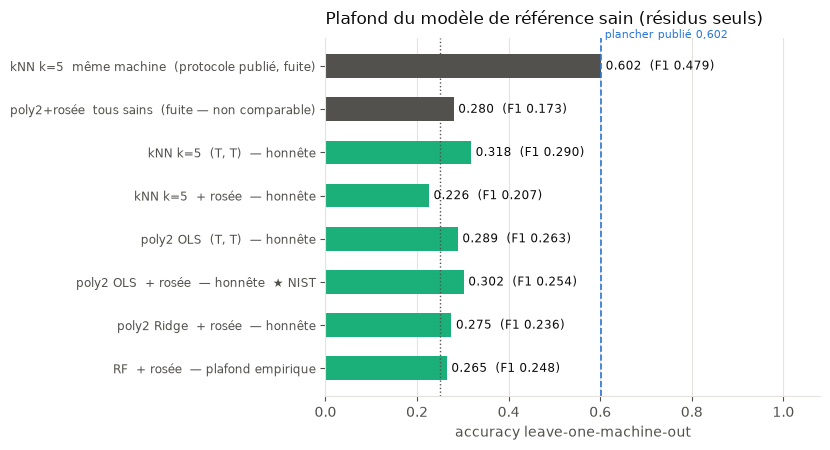

In [4]:
honest = perf[perf.honnête]
accs = perf['LOMO acc'].to_numpy()
f1s = perf['LOMO F1'].to_numpy()
colors = np.array([AQUA if h else MUTED for h in perf.honnête])
order = np.arange(len(perf))[::-1]  # première ligne du tableau en haut

fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.barh(np.arange(len(perf)), accs[order], color=colors[order], height=0.55)
for i, (acc, f1) in enumerate(zip(accs[order], f1s[order])):
    ax.text(acc + 0.01, i, f'{acc:.3f}  (F1 {f1:.3f})', va='center', fontsize=8.5, color=INK)
ax.axvline(0.602, color=BLUE, linewidth=1.2, linestyle='--')
ax.text(0.610, len(perf) - 0.35, 'plancher publié 0,602', fontsize=8, color=BLUE)
ax.axvline(MAJ, color=MUTED, linewidth=1.0, linestyle=':')
ax.set_yticks(np.arange(len(perf)))
ax.set_yticklabels(perf.index[order], fontsize=8.5)
ax.set_xlim(0, 1.08)
ax.set_xlabel('accuracy leave-one-machine-out')
ax.set_title('Plafond du modèle de référence sain (résidus seuls)', loc='left', color=INK, pad=10)
ax.grid(axis='y', visible=False)
plt.tight_layout()

best_name = honest['LOMO acc'].idxmax()
best_acc = float(honest.loc[best_name, 'LOMO acc'])
best_f1 = float(honest.loc[best_name, 'LOMO F1'])
print(f'meilleure variante honnête : {best_name}')
print(f'LOMO acc={best_acc:.3f}  F1={best_f1:.3f}')
if best_acc < 0.40:
    verdict = (
        f'Plafond transféré ≈ {best_acc:.2f} — à peine au-dessus de la classe majoritaire '
        f'({MAJ:.2f}). Aucune référence apprise sur l’autre machine ne bat le 0,60. '
        'Le 0,602 n’était pas un plancher transférable : il calibrate sur les sains '
        'de la machine de test. Ça ne vaut pas le coup de monter la référence en .py.'
    )
elif best_acc < 0.65:
    verdict = (
        f'Plafond ≈ {best_acc:.2f}. Le gain vs 0,60 est trop mince : '
        'ça ne vaut pas le coup de monter la référence en production.'
    )
elif best_acc < 0.80:
    verdict = (
        f'Plafond ≈ {best_acc:.2f}. Gain réel vs 0,60, pas un saut à 0,80. '
        'Utile si on bascule sur du réel ; pas un argument de perf spectaculaire.'
    )
else:
    verdict = (
        f'Plafond ≈ {best_acc:.2f}. La référence saine change l’ordre de grandeur du transfert.'
    )
print('\n' + verdict)

## Lecture

- La ligne **kNN même machine** doit retomber vers **0,602 / 0,479**. Écart de quelques points :
  une ligne `Rated_SEER` NaN, sinon le classifieur ou le jeu a changé.
- Les lignes **honnêtes** sont le chiffre qui compte. Si elles collent à la classe majoritaire
  (~0,25), le 0,602 n'était **pas** un plancher transférable : c'était une calibration
  sur les essais sains de la machine de test. Un polynôme NIST, le point de rosée ou une RF
  n'y changent rien — le COP sain des deux machines n'est pas la même surface
  (biais `d_COP` de l'ordre de ±0,5).
- La ligne **tous sains** (un modèle unique) n'atteint pas 0,85 sous LOMO. Le 0,85/0,95
  est le piège du **CV aléatoire**, déjà mesuré dans `EDA_NIST_model.ipynb`. Ici, un polynôme
  unique n'arrive même pas à décrire les deux machines à la fois.
- Hors périmètre : `src/` n'est pas modifié. La montée en `.py` est une phase suivante.